# Chapter 6 — Lenses

Companion tutorial for **[Foundations of Computer Vision](https://visionbook.mit.edu/lenses.html)** by Torralba, Isola, and Freeman (MIT Press, 2024).

This is the lens chapter of Part II (Image Formation), and it answers a question pinholes can't: how do you let in more light without sacrificing sharpness? Three ideas drive it:

1. **The lensmaker's formula** turns Snell's law plus a small-angle approximation into one equation, $1/a + 1/b = 1/f$, relating object distance, image distance, and focal length.
2. **Depth of field** falls out of the same geometry: the band of object distances around the focal plane that still appears sharp scales as $D \approx 2NCU^2/f^2$ in the f-number $N$.
3. **A telescope is two lenses sharing a focal point.** A Galilean telescope's angular magnification is $f_1/f_2$, derivable from the same ray-tracing as the lensmaker's formula.

We reproduce the chapter's diagrammatic figures; for the chapter's photographic demos we substitute synthetic versions computed from the same physics. The most interesting bits live in the depth-of-field section, where a Kornia depth-dependent blur recreates the f/2-vs-f/8 comparison from first principles, and at the end, where two of our thin-lens helpers compose into a telescope with no new code.

In [2]:
from pathlib import Path

import torch
import kornia
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, Circle, FancyArrowPatch
from matplotlib.collections import LineCollection

# Geometric-optics figures stay device-agnostic; the depth-of-field section
# (which renders per-pixel blur) uses DEVICE to run on GPU when available.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(0)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": False,
})

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)


## 6.2 — Lensmaker's Formula

A lens refracts light at each of its two surfaces. The lensmaker's formula compresses that two-refraction process into one equation,

$$\frac{1}{a} + \frac{1}{b} = \frac{1}{f},$$

relating object distance $a$, image distance $b$, and focal length $f$. We derive it by applying Snell's law twice with the small-angle approximation $\sin\theta \approx \theta$ — the *paraxial* regime where the algebra stays linear (book §6.2).

**Notation for this section.**

| Symbol | Meaning |
|---|---|
| $n$ | Index of refraction of a material. The speed of light in the material is $c/n$, where $c$ is its speed in vacuum. Air is $n = 1$, lens glass is roughly $n = 1.5$. |
| $\theta_1, \theta_2$ | Incidence and refraction angles at a flat interface, measured from the surface normal (Snell's law). |
| $a$ | Distance along the optical axis from an object point to the lens. |
| $b$ | Distance from the lens to the image of that object. |
| $c$ | Height above the optical axis where a ray meets the lens surface. |
| $R$ | Radius of curvature of a spherical lens surface. A full lens has $R_1$ and $R_2$ for its two surfaces. |
| $\theta_S$ | Angle the lens surface makes with the optical axis at height $c$. |
| $f$ | Focal length of the lens. |

Inside the thin-lens derivation, the book labels the four sequential ray angles $\theta_1, \theta_2, \theta_3, \theta_4$ (Table 6.1 of the book). The collision with the Snell-law $\theta_1, \theta_2$ above is the book's notation; we disambiguate by context.

In [3]:
# Section 6.2 — physics primitives.
# Snell's law and its paraxial small-angle form, the surface-tilt angle, the
# lensmaker's focal length and conjugate image distance, and the four-angle
# bookkeeping that the thin-lens derivation composes from them. (Book §6.2.)


def snells_law(n1, n2, theta1):
    """Refraction angle θ₂ at a flat interface (n₁ sin θ₁ = n₂ sin θ₂).

    Angles in radians, measured from the surface normal. Returns NaN past
    the critical angle (total internal reflection).
    """
    n1 = torch.as_tensor(n1, dtype=torch.float32)
    n2 = torch.as_tensor(n2, dtype=torch.float32)
    theta1 = torch.as_tensor(theta1, dtype=torch.float32)
    return torch.asin((n1 / n2) * torch.sin(theta1))


def paraxial_snell(n1, n2, theta1):
    """Paraxial Snell's law: n1·θ1 = n2·θ2, the small-angle form of snells_law.

    Differs from snells_law by sin(θ) ≈ θ. Used throughout §6.2's lensmaker
    derivation where the four ray angles all sit in the paraxial regime.
    Angles in radians, measured from the surface normal.
    """
    n1 = torch.as_tensor(n1, dtype=torch.float32)
    n2 = torch.as_tensor(n2, dtype=torch.float32)
    theta1 = torch.as_tensor(theta1, dtype=torch.float32)
    return (n1 / n2) * theta1


def surface_angle(c, R):
    """Tilt angle θ_S of a spherical surface at height c, radius R.

    Paraxial form: θ_S ≈ c/R. (Book §6.2, Figure 6.5.)
    """
    c = torch.as_tensor(c, dtype=torch.float32)
    R = torch.as_tensor(R, dtype=torch.float32)
    return c / R


def focal_length(n, R1, R2):
    """Focal length of a thin lens via the lensmaker's equation.

    1/f = (n-1) * (1/R1 + 1/R2).  (Book §6.2, Eq. derived from Table 6.1.)
    Sign convention: both R1 and R2 are positive magnitudes. A biconvex lens
    has R1 > 0 and R2 > 0. (Book §6.2 — note this differs from Hecht 2016,
    which uses signed radii.)
    """
    n = torch.as_tensor(n, dtype=torch.float32)
    R1 = torch.as_tensor(R1, dtype=torch.float32)
    R2 = torch.as_tensor(R2, dtype=torch.float32)
    return 1.0 / ((n - 1.0) * (1.0 / R1 + 1.0 / R2))


def image_distance(a, f):
    """Image distance b from object distance a and focal length f.

    1/a + 1/b = 1/f  =>  b = a*f / (a - f).  (Book §6.2.)
    Returns inf when a == f (object at the focal point → image at infinity).
    """
    a = torch.as_tensor(a, dtype=torch.float32)
    f = torch.as_tensor(f, dtype=torch.float32)
    return a * f / (a - f)


def lensmaker_angle_bookkeeping(n, R1, R2, c, theta1_deg):
    """Compute the four paraxial ray angles and two surface tilts through a thin lens.

    Applies paraxial Snell's law at each surface using the helpers defined
    above. Returns (theta1_axis, theta2_axis, theta4_axis, thetaS1, thetaS2),
    all in radians measured from the optical axis (rays) or from horizontal
    (surface tilts). (Book §6.2, Table 6.1.)
    """
    theta1_axis = torch.deg2rad(theta1_deg)

    # Surface tilts at the ray's hit height (both radii now positive magnitudes
    # per the book's convention).
    thetaS1 = surface_angle(c, R1)
    thetaS2 = surface_angle(c, R2)

    # Refract entering the glass at the front surface.
    theta1_normal = theta1_axis + thetaS1
    theta2_normal = paraxial_snell(1.0, n, theta1_normal)
    theta2_axis = theta2_normal - thetaS1

    # Refract exiting the glass at the back surface.
    theta3_normal = thetaS2 - theta2_axis
    theta4_normal = paraxial_snell(n, 1.0, theta3_normal)
    theta4_axis = thetaS2 - theta4_normal

    return theta1_axis, theta2_axis, theta4_axis, thetaS1, thetaS2


# Sanity checks — one per function.
# Snell's law: 30° in air → ≈19.47° in glass (n=1.5).
print(f"{torch.rad2deg(snells_law(1.0, 1.5, torch.deg2rad(torch.tensor(30.0)))).item():.2f}°")
# Paraxial Snell: 5° in air → ≈3.33° in glass (n=1.5), close to exact 3.33°.
print(f"{torch.rad2deg(paraxial_snell(1.0, 1.5, torch.deg2rad(torch.tensor(5.0)))).item():.2f}°")
# Surface tilt: radius 50 mm, ray hit at height 5 mm → about 0.1 rad ≈ 5.73°.
print(f"{torch.rad2deg(surface_angle(5.0, 50.0)).item():.2f}°")
# Biconvex lens, n=1.5, R1=R2=50 mm → f = 50 mm. Object at 200 mm → b ≈ 67 mm.
f = focal_length(1.5, 50.0, 50.0)
b = image_distance(200.0, f)
print(f"f = {f.item():.2f} mm, b(a=200) = {b.item():.2f} mm")

19.47°
3.33°
5.73°
f = 50.00 mm, b(a=200) = 66.67 mm


For small angles in radians, $\sin\theta \approx \theta$, and Snell's law at a glass-air interface ($n_1 = 1$, $n_2 = n$) becomes the linear $\theta_1 = n\theta_2$. The book uses this paraxial form throughout the rest of the section.

### The lensmaker's formula in two steps

Applying paraxial Snell's law at the front surface and again at the back, then summing the four angles a ray makes along its path from object to image (book Table 6.1), yields

$$\frac{1}{a} + \frac{1}{b} = (n-1)\left(\frac{1}{R_1} - \frac{1}{R_2}\right).$$

The right-hand side depends only on the lens — its refractive index and the curvatures of its two surfaces. Defining the *focal length* $f$ as

$$\frac{1}{f} = (n-1)\left(\frac{1}{R_1} - \frac{1}{R_2}\right)$$

collapses the relation to the form we set out to derive,

$$\frac{1}{a} + \frac{1}{b} = \frac{1}{f}.$$

Two helpers below: one computes $f$ from a lens's physical parameters; the other solves the conjugate-point relation for the image distance $b$ given an object distance $a$.

**Figure 6.3(a) — Snell's law at a flat interface.** A ray crosses from a medium with refractive index $n_1$ into a denser medium with $n_2 > n_1$ and bends toward the normal. The angles $\theta_1, \theta_2$ are measured from the normal, and $n_1 \sin\theta_1 = n_2 \sin\theta_2$ relates them. The book's panel (b), a photograph of a straw refracting in a glass of water, is the same physics in the physical world; we don't reproduce the photo here. (Book §6.2, Figure 6.3.)

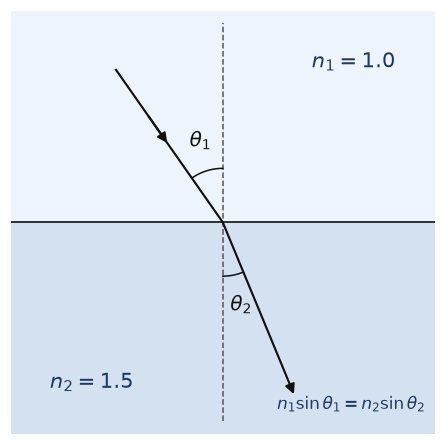

In [14]:
# Figure 6.3 (a) — Snell's law at a flat interface (book §6.2).
#
# This cell draws one incident ray crossing a flat interface between two media.
# The tunable parameters below set the two refractive indices and the incident
# angle; rerunning the cell recomputes the refracted angle from Snell's law and
# redraws the ray, angle markers, and labels from those physical values.

# --- Tunable physics parameters ---
# The parameters below drive the figure's geometry within a narrow range
# around the defaults. If n1 * sin(theta1) exceeds n2, total internal reflection
# occurs and this transmitted-ray drawing is no longer the correct physical case.
n1 = torch.tensor(1.0, dtype=torch.float32)
n2 = torch.tensor(1.5, dtype=torch.float32)
theta1_deg = torch.tensor(35.0, dtype=torch.float32)

ray_len = torch.tensor(1.45, dtype=torch.float32)
angle_radius = torch.tensor(0.42, dtype=torch.float32)
label_radius = torch.tensor(0.64, dtype=torch.float32)
interface_half_width = torch.tensor(1.70, dtype=torch.float32)
normal_half_height = torch.tensor(1.55, dtype=torch.float32)

# --- Derived quantities ---
zero = torch.tensor(0.0, dtype=torch.float32)
pi = torch.tensor(torch.pi, dtype=torch.float32)

theta1 = torch.deg2rad(theta1_deg)
theta2 = snells_law(n1, n2, theta1)

origin = torch.stack([zero, zero])

# Directions are measured from the surface normal. The incident ray travels
# down and right toward the interface; the refracted ray leaves down and right
# with the angle recomputed by Snell's law.
incident_dir = torch.stack([torch.sin(theta1), -torch.cos(theta1)])
refracted_dir = torch.stack([torch.sin(theta2), -torch.cos(theta2)])

source = -ray_len * incident_dir
incoming_pre_hit = -torch.tensor(0.12, dtype=torch.float32) * incident_dir
refracted_tip = ray_len * refracted_dir

# Reference directions for the angle markers.
normal_up = 0.5 * pi
normal_down = -0.5 * pi
incident_from_origin = normal_up + theta1
refracted_from_origin = normal_down + theta2

blue_tint_top = "#eef4fb"
blue_tint_bottom = "#d4e1f0"
dark = "#111111"
gray = "#555555"
label_blue = "#1f3a5f"

# --- Drawing ---
fig, ax = plt.subplots(figsize=(6.2, 5.0))

# Fill the two media on either side of the flat interface.
ax.axhspan(0.0, interface_half_width.item(), color=blue_tint_top, zorder=0)
ax.axhspan(-interface_half_width.item(), 0.0, color=blue_tint_bottom, zorder=0)

# Draw the interface and the normal through the incidence point.
ax.plot(
    [-interface_half_width.item(), interface_half_width.item()],
    [0.0, 0.0],
    color="0.20",
    lw=1.3,
    zorder=2,
)
ax.plot(
    [0.0, 0.0],
    [-normal_half_height.item(), normal_half_height.item()],
    color=gray,
    lw=1.0,
    ls="--",
    zorder=2,
)

# Draw the incident ray as a line ending at the interface.
ax.plot(
    [source[0].item(), origin[0].item()],
    [source[1].item(), origin[1].item()],
    color=dark,
    lw=1.4,
    zorder=3,
)

# Add a small direction marker on the incident ray.
incoming_arrow_start = source + torch.tensor(0.42, dtype=torch.float32) * incident_dir
incoming_arrow_end = source + torch.tensor(0.72, dtype=torch.float32) * incident_dir
ax.add_patch(
    FancyArrowPatch(
        (incoming_arrow_start[0].item(), incoming_arrow_start[1].item()),
        (incoming_arrow_end[0].item(), incoming_arrow_end[1].item()),
        arrowstyle="-|>",
        mutation_scale=13,
        lw=1.4,
        color=dark,
        zorder=4,
    )
)

# Draw the refracted ray leaving the interface.
ax.add_patch(
    FancyArrowPatch(
        (origin[0].item(), origin[1].item()),
        (refracted_tip[0].item(), refracted_tip[1].item()),
        arrowstyle="-|>",
        mutation_scale=13,
        lw=1.4,
        color=dark,
        shrinkA=0,
        shrinkB=0,
        zorder=3,
    )
)

# Mark the two measured angles from the normal.
draw_angle(
    ax,
    origin,
    normal_up,
    incident_from_origin,
    angle_radius,
    r"$\theta_1$",
    text_radius=label_radius,
    text_shift=torch.tensor([0.02, 0.02], dtype=torch.float32),
    fs=13,
    color=dark,
    lw=1.0,
    z=5,
)
draw_angle(
    ax,
    origin,
    normal_down,
    refracted_from_origin,
    angle_radius,
    r"$\theta_2$",
    text_radius=label_radius,
    text_shift=torch.tensor([0.02, -0.02], dtype=torch.float32),
    fs=13,
    color=dark,
    lw=1.0,
    z=5,
)

# Label the two media using the current refractive-index values.
ax.text(
    1.02,
    1.25,
    rf"$n_1 = {n1.item():.1f}$",
    ha="center",
    va="center",
    fontsize=14,
    color=label_blue,
)
ax.text(
    -1.02,
    -1.25,
    rf"$n_2 = {n2.item():.1f}$",
    ha="center",
    va="center",
    fontsize=14,
    color=label_blue,
)

# Place Snell's law in the open lower-right part of the denser medium.
ax.text(
    1.00,
    -1.42,
    r"$n_1 \sin\theta_1 = n_2 \sin\theta_2$",
    ha="center",
    va="center",
    fontsize=11,
    color=label_blue,
)

ax.set_xlim(-1.65, 1.65)
ax.set_ylim(-1.65, 1.65)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")

# --- Save ---
plt.savefig(IMAGES_DIR / "fig06_03a.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure 6.4(a) — Thin-lens geometry.** A point on the optical axis at distance $a$ from the lens emits rays in many directions. Those rays pass through the lens at various heights up to $c$ and converge to a single image point at distance $b$ on the other side. The angle the lowest extreme ray makes with the optical axis is $\theta_1$ on the object side and $\theta_4$ on the image side. The lensmaker's formula derived in this section is the statement that for a thin lens, this convergence happens at the same $b$ for every ray emitted from the same object point. (Book §6.2, Figure 6.4(a).)

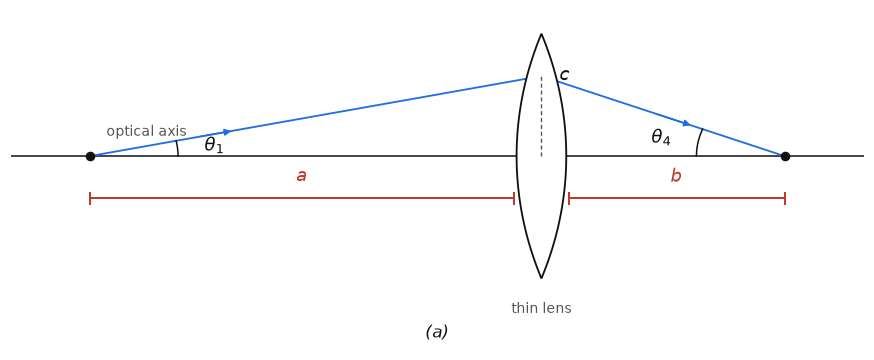

In [15]:
# Figure 6.4 (a) — Thin-lens geometry (book §6.2).
#
# This cell draws the single-ray thin-lens construction from the book: one ray
# leaves the object point, reaches the thin lens at height c, and reconverges
# to the image point. The parameters below drive the lens material, surface
# curvature, object distance, and ray height; the focal length and image
# distance are computed from those inputs via the lensmaker's formula and the
# thin-lens equation, so changing any value and rerunning redraws the full
# construction from the updated physics.

# --- Tunable physics parameters ---
# The parameters below drive the figure's geometry within a narrow range
# around the defaults. Significant deviations may push labels off-figure or
# stretch the lens outline, because some layout constants are still chosen
# for readability. The geometry itself remains consistent with the inputs.
n = torch.tensor(1.5, dtype=torch.float32)                  # glass refractive index
R1 = torch.tensor(1.4, dtype=torch.float32)                 # front surface radius of curvature
R2 = torch.tensor(1.4, dtype=torch.float32)                 # back surface radius of curvature
a = torch.tensor(4.0, dtype=torch.float32)                  # object distance from lens
c = torch.tensor(0.85, dtype=torch.float32)                 # ray height at lens

# --- Visual layout knobs (cosmetic, no physics meaning) ---
lens_half_height = torch.tensor(1.30, dtype=torch.float32)             # half-height of drawn lens
lens_axis_half_thickness = torch.tensor(0.22, dtype=torch.float32)     # half-thickness at axis
angle_arc_radius = torch.tensor(0.78, dtype=torch.float32)
bracket_y = torch.tensor(-0.45, dtype=torch.float32)
tick = torch.tensor(0.06, dtype=torch.float32)

# --- Derived quantities ---
# Compute the focal length from the lensmaker's formula, then the image
# distance from the thin-lens equation, then the endpoint ray angles.
f = focal_length(n, R1, R2)
b = image_distance(a, f)
theta1 = torch.atan(c / a)
theta4 = torch.atan(c / b)

# Build the lens as two circular arcs that meet at the top and bottom rim
# points and bulge outward to the chosen axis thickness.
cx = (lens_axis_half_thickness**2 - lens_half_height**2) / (2.0 * lens_axis_half_thickness)
R = torch.sqrt(cx**2 + lens_half_height**2)

y_lens = torch.linspace(-lens_half_height, lens_half_height, 240, dtype=torch.float32)
x_half = cx + torch.sqrt(torch.clamp(R**2 - y_lens**2, min=0.0))

right_edge = torch.stack([x_half, y_lens], dim=1)
left_edge = torch.stack([-x_half.flip(0), y_lens.flip(0)], dim=1)
lens_xy = torch.cat([right_edge, left_edge], dim=0)

# Sample the two angle arcs directly as tensors so the entire construction
# stays in torch until the plotting call sites.
s = torch.linspace(0.0, 1.0, 60, dtype=torch.float32)
arc_left = s * theta1
arc_right = torch.pi - s * theta4

# Precompute the key points used throughout the drawing.
obj = torch.stack([-a, torch.tensor(0.0, dtype=torch.float32)])
lens_hit = torch.stack([torch.tensor(0.0, dtype=torch.float32), c])
img = torch.stack([b, torch.tensor(0.0, dtype=torch.float32)])

# Choose a small lens gap for the distance brackets so the a and b spans read
# as separate measurements rather than one continuous line.
bracket_gap = lens_axis_half_thickness + torch.tensor(0.02, dtype=torch.float32)

blue = "#1f6fe0"
dark = "#111111"
gray = "#555555"
red = "#c0392b"

# --- Drawing ---
fig, ax = plt.subplots(figsize=(10, 4))

# Draw the optical axis across the figure and place its label in clear space
# above the object-side half of the axis.
ax.axhline(0.0, color=dark, lw=1.0, zorder=1)
ax.text(-3.5, 0.18, "optical axis", fontsize=9, color=gray, ha="center", va="bottom")

# Draw the thin lens centered at x = 0.
ax.add_patch(
    Polygon(
        [(p[0].item(), p[1].item()) for p in lens_xy],
        closed=True,
        facecolor="white",
        edgecolor=dark,
        lw=1.2,
        zorder=3,
    )
)
ax.text(0.0, -1.55, "thin lens", fontsize=9, color=gray, ha="center", va="top")

# Draw one ray as two straight segments with the bend at the thin lens.
ax.plot(
    [obj[0].item(), lens_hit[0].item()],
    [obj[1].item(), lens_hit[1].item()],
    color=blue,
    lw=1.2,
    zorder=2,
)
ax.plot(
    [lens_hit[0].item(), img[0].item()],
    [lens_hit[1].item(), img[1].item()],
    color=blue,
    lw=1.2,
    zorder=2,
)

# Add small direction markers on the incoming and outgoing halves of the ray.
incoming_start = obj + torch.tensor([0.95, 0.95 * (c / a).item()], dtype=torch.float32)
incoming_end = obj + torch.tensor([1.28, 1.28 * (c / a).item()], dtype=torch.float32)
ax.add_patch(
    FancyArrowPatch(
        (incoming_start[0].item(), incoming_start[1].item()),
        (incoming_end[0].item(), incoming_end[1].item()),
        arrowstyle="-|>",
        mutation_scale=9,
        color=blue,
        lw=1.0,
        zorder=4,
    )
)

outgoing_dx = torch.tensor(1.00, dtype=torch.float32)
outgoing_start = lens_hit + torch.stack([outgoing_dx, -outgoing_dx * c / b])
outgoing_end = lens_hit + torch.stack([outgoing_dx + 0.35, -(outgoing_dx + 0.35) * c / b])
ax.add_patch(
    FancyArrowPatch(
        (outgoing_start[0].item(), outgoing_start[1].item()),
        (outgoing_end[0].item(), outgoing_end[1].item()),
        arrowstyle="-|>",
        mutation_scale=9,
        color=blue,
        lw=1.0,
        zorder=4,
    )
)

# Mark the object and image points as black dots.
ax.scatter(
    [obj[0].item(), img[0].item()],
    [obj[1].item(), img[1].item()],
    s=28,
    color=dark,
    zorder=5,
)

# Draw the dashed height marker c at the lens plane and label it near the top.
ax.plot(
    [0.0, 0.0],
    [0.0, c.item()],
    color=gray,
    lw=0.9,
    ls=(0, (3, 2)),
    zorder=4,
)
ax.text(0.16, c.item(), r"$c$", fontsize=12, color=dark, ha="left", va="center")

# Draw the angle marker for theta_1 at the object end.
x_left_arc = obj[0] + angle_arc_radius * torch.cos(arc_left)
y_left_arc = angle_arc_radius * torch.sin(arc_left)
ax.plot(
    [v.item() for v in x_left_arc],
    [v.item() for v in y_left_arc],
    color=dark,
    lw=1.0,
    zorder=4,
)
theta1_mid = 0.5 * theta1
theta1_text = obj + (angle_arc_radius + torch.tensor(0.24, dtype=torch.float32)) * torch.stack(
    [torch.cos(theta1_mid), torch.sin(theta1_mid)]
)
ax.text(
    theta1_text[0].item(),
    theta1_text[1].item(),
    r"$\theta_1$",
    fontsize=12,
    color=dark,
    ha="left",
    va="center",
)

# Draw the angle marker for theta_4 at the image end.
x_right_arc = img[0] + angle_arc_radius * torch.cos(arc_right)
y_right_arc = angle_arc_radius * torch.sin(arc_right)
ax.plot(
    [v.item() for v in x_right_arc],
    [v.item() for v in y_right_arc],
    color=dark,
    lw=1.0,
    zorder=4,
)
theta4_mid = torch.pi - 0.5 * theta4
theta4_text = img + (angle_arc_radius + torch.tensor(0.24, dtype=torch.float32)) * torch.stack(
    [torch.cos(theta4_mid), torch.sin(theta4_mid)]
)
ax.text(
    theta4_text[0].item(),
    theta4_text[1].item(),
    r"$\theta_4$",
    fontsize=12,
    color=dark,
    ha="right",
    va="center",
)

# Draw the object-distance bracket a below the axis.
ax.plot(
    [obj[0].item(), -bracket_gap.item()],
    [bracket_y.item(), bracket_y.item()],
    color=red,
    lw=1.3,
    zorder=4,
)
ax.plot(
    [obj[0].item(), obj[0].item()],
    [(bracket_y - tick).item(), (bracket_y + tick).item()],
    color=red,
    lw=1.3,
    zorder=4,
)
ax.plot(
    [-bracket_gap.item(), -bracket_gap.item()],
    [(bracket_y - tick).item(), (bracket_y + tick).item()],
    color=red,
    lw=1.3,
    zorder=4,
)
ax.text(
    (-0.5 * (a + bracket_gap)).item(),
    (bracket_y + torch.tensor(0.13, dtype=torch.float32)).item(),
    r"$a$",
    fontsize=12,
    color=red,
    ha="center",
    va="bottom",
)

# Draw the image-distance bracket b below the axis.
ax.plot(
    [bracket_gap.item(), img[0].item()],
    [bracket_y.item(), bracket_y.item()],
    color=red,
    lw=1.3,
    zorder=4,
)
ax.plot(
    [bracket_gap.item(), bracket_gap.item()],
    [(bracket_y - tick).item(), (bracket_y + tick).item()],
    color=red,
    lw=1.3,
    zorder=4,
)
ax.plot(
    [img[0].item(), img[0].item()],
    [(bracket_y - tick).item(), (bracket_y + tick).item()],
    color=red,
    lw=1.3,
    zorder=4,
)
ax.text(
    (0.5 * (b + bracket_gap)).item(),
    (bracket_y + torch.tensor(0.13, dtype=torch.float32)).item(),
    r"$b$",
    fontsize=12,
    color=red,
    ha="center",
    va="bottom",
)

# Draw the panel label centered below the figure.
ax.text(
    (0.5 * (img[0] - a)).item(),
    -1.88,
    "(a)",
    fontsize=11,
    style="italic",
    color=dark,
    ha="center",
    va="center",
)

ax.set_xlim((-a - torch.tensor(0.7, dtype=torch.float32)).item(), (b + torch.tensor(0.7, dtype=torch.float32)).item())
ax.set_ylim(-2.05, 1.55)
ax.axis("off")

# --- Save ---
plt.savefig(IMAGES_DIR / "fig06_04a.png", dpi=150, bbox_inches="tight")
plt.show()

The figure depicts an idealization: rays appear to bend at a single point (the center of the lens) rather than refracting twice (at each glass surface). This is the *thin-lens approximation*, which assumes the lens's physical thickness is small enough to ignore. Panel (b), drawn next, distorts the geometry to expose the actual two-surface bending that the thin-lens approximation glosses over.

**Figure 6.4(b) — The labeled thin-lens geometry.** To derive the lensmaker's formula we follow a *single* ray as it refracts twice — once at each lens surface — and track the four angles $\theta_1, \theta_2, \theta_3, \theta_4$ it turns through, along with the surface-tilt angle $\theta_S$ at the height $c$ where it crosses. Panel (b) is the same lens as panel (a), redrawn with its geometry deliberately distorted — the two surfaces pulled apart and the angles enlarged — so every label is legible. The thin-lens assumption is made explicit by the small gap $d \approx 0$ between the surfaces. These are exactly the quantities Table 6.1 of the book sums.

In [6]:
# Shared helpers — drawing primitives reused across Chapter 6 figures.


def draw_angle(ax, center, angle_a, angle_b, radius, text=None, text_radius=None, text_shift=None, fs=9.8, color="0.25", lw=0.85, z=7):
    """Draw one angle arc between two tensor-defined directions."""
    # Sweep the smaller signed arc from angle_a toward angle_b.
    delta = torch.atan2(torch.sin(angle_b - angle_a), torch.cos(angle_b - angle_a))
    a0, a1 = angle_a, angle_a + delta
    # Sample the arc directly as a tensor span — no .item() round-trip into linspace.
    t = a0 + (a1 - a0) * torch.linspace(0.0, 1.0, 80, dtype=torch.float32)

    x = center[0] + radius * torch.cos(t)
    y = center[1] + radius * torch.sin(t)
    ax.plot([v.item() for v in x], [v.item() for v in y], color=color, lw=lw, zorder=z)

    if text is not None:
        if text_radius is None:
            text_radius = radius + torch.tensor(0.20, dtype=torch.float32)
        if text_shift is None:
            text_shift = torch.tensor([0.0, 0.0], dtype=torch.float32)

        mid_angle = 0.5 * (a0 + a1)
        text_point = center + text_radius * torch.stack([torch.cos(mid_angle), torch.sin(mid_angle)]) + text_shift
        ax.text(text_point[0].item(), text_point[1].item(), text, fontsize=fs, color=color, ha="center", va="center")


def lens_curves(gap, bulge, half_h, samples=320):
    """Compute the two curved sides of a biconvex lens."""
    y = torch.linspace(-half_h, half_h, samples)
    y_unit = y / half_h
    profile = torch.sqrt(torch.clamp(1.0 - y_unit**2, min=0.0))
    left_x = -gap - bulge * profile
    right_x = gap + bulge * profile
    return left_x, right_x, y


def surface_x_at_y(y, gap, bulge, half_h, side):
    """Compute where a curved lens surface sits at a given ray height."""
    y_unit = y / half_h
    profile = torch.sqrt(torch.clamp(1.0 - y_unit**2, min=0.0))
    if side == "left":
        return -gap - bulge * profile
    return gap + bulge * profile


def draw_biconvex_lens(ax, left_x, right_x, y, face="#dbe7f5", lw=1.45, alpha=0.95):
    """Draw a filled biconvex lens body from tensor-defined surface curves."""
    boundary = [(left_x[i].item(), y[i].item()) for i in range(y.numel())]
    boundary += [(right_x[i].item(), y[i].item()) for i in range(y.numel() - 1, -1, -1)]

    ax.add_patch(
        Polygon(
            boundary,
            closed=True,
            facecolor=face,
            edgecolor="none",
            alpha=alpha,
            zorder=1,
        )
    )
    ax.plot([v.item() for v in left_x], [v.item() for v in y], color="black", lw=lw, zorder=3)
    ax.plot([v.item() for v in right_x], [v.item() for v in y], color="black", lw=lw, zorder=3)


def solve_surface_hit_from_ray(front_hit, theta_axis, gap, bulge, half_h):
    """Find where the in-glass ray intersects the back curved surface."""
    slope = torch.tan(theta_axis)
    y_candidates = torch.linspace(-0.95 * half_h, 0.95 * half_h, 2000)
    x_candidates = surface_x_at_y(y_candidates, gap, bulge, half_h, side="right")
    y_on_ray = front_hit[1] + slope * (x_candidates - front_hit[0])
    idx = torch.argmin(torch.abs(y_candidates - y_on_ray))
    return torch.stack([x_candidates[idx], y_candidates[idx]])


def visually_exaggerate_angle(angle, scale, min_deg, max_deg):
    """Scale a small display angle while preserving its sign."""
    mag_deg = torch.rad2deg(torch.abs(angle))
    mag_deg_vis = torch.clamp(mag_deg * scale, min=min_deg, max=max_deg)
    return torch.sign(angle) * torch.deg2rad(mag_deg_vis)


def draw_surface_slice(ax, hit, side):
    """Draw one short local surface slice with faint glass fill."""
    t = torch.linspace(-1.0, 1.0, 140)
    y = hit[1] + 1.05 * t

    if side == "front":
        x = hit[0] + 0.16 * t**2
        fill = [(x[i].item(), y[i].item()) for i in range(t.numel())]
        fill += [
            (hit[0].item() + 1.20, (hit[1] + 1.05 * t[i]).item())
            for i in range(t.numel() - 1, -1, -1)
        ]
    else:
        x = hit[0] - 0.16 * t**2
        fill = [
            (hit[0].item() - 1.20, (hit[1] + 1.05 * t[i]).item())
            for i in range(t.numel())
        ]
        fill += [(x[i].item(), y[i].item()) for i in range(t.numel() - 1, -1, -1)]

    ax.add_patch(
        Polygon(
            fill,
            closed=True,
            facecolor="#dbe7f5",
            edgecolor="none",
            alpha=0.80,
            zorder=1,
        )
    )
    ax.plot([v.item() for v in x], [v.item() for v in y], color="black", lw=1.2, zorder=4)

**Reading Figure 6.4(b).** The cell below renders two coordinated views of the *same* ray crossing the lens. On the left is the full labeled construction: a single ray leaves the on-axis object point, refracts at the front surface, travels through the glass, refracts again at the back surface, and meets the axis at the image point — distances and angles deliberately distorted so every label stays legible. On the right, an angle inset zooms into each surface in turn, isolating the local geometry Snell's law acts on: the surface normal (tilted by $\theta_S \approx c/R$ at the crossing height $c$), the incident ray, and the refracted ray. Measuring the ray angles from the optical axis and applying the paraxial Snell's law ($n_1\sin\theta \approx n_1\theta$) at each surface gives the two relations the derivation sums:

$$n\,\theta_2 = \theta_1 + \theta_S, \qquad n\,\theta_3 = \theta_4 + \theta_S.$$

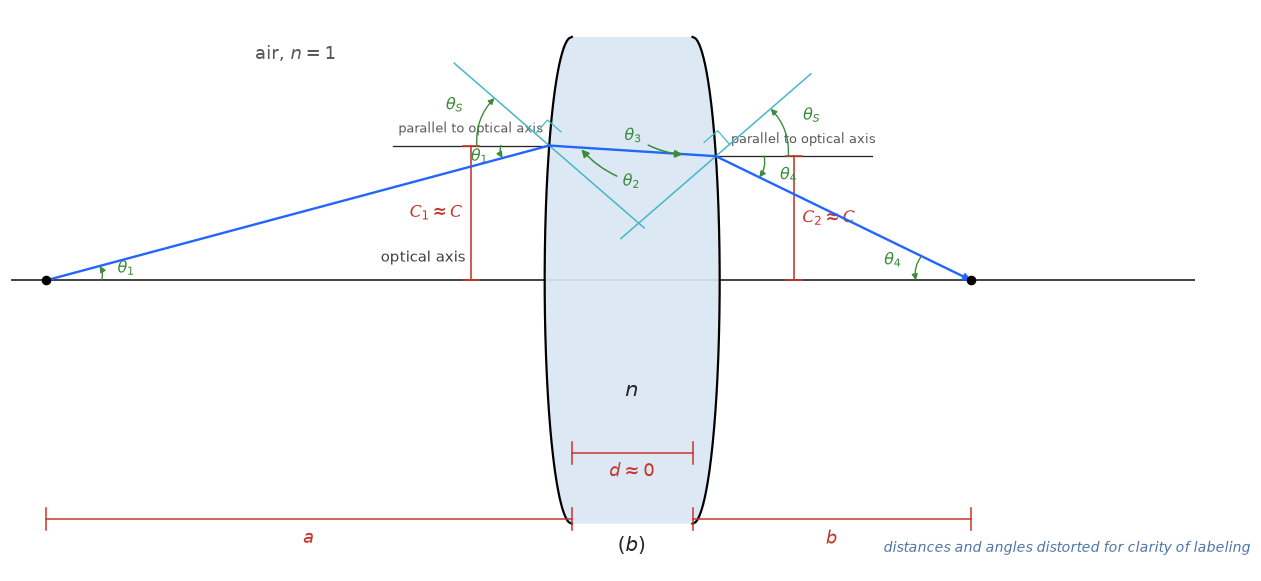

In [7]:
# Figure 6.4 (b) — Thin-lens angle geometry (book §6.2).
#
# This cell draws the book-style lens diagram.
# The parameters below drive the ray path, surface normals, distance brackets,
# and angle bookkeeping; changing a value and rerunning redraws the figure
# from the updated geometry.

# --- Tunable physics parameters ---
# The parameters below drive the figure's geometry within a narrow range
# around the defaults. Significant deviations may push labels off-figure or
# break the lens-shape proportions, because some visual layout constants are
# not yet coupled to the physics. The math itself remains correct for any inputs.
n = torch.tensor(1.5, dtype=torch.float32)
R1 = torch.tensor(1.4, dtype=torch.float32)
R2 = torch.tensor(1.4, dtype=torch.float32)
c = torch.tensor(1.0, dtype=torch.float32)
theta1_deg = torch.tensor(15.0, dtype=torch.float32)
exaggeration = torch.tensor(5.0, dtype=torch.float32)

theta23_scale = torch.tensor(2.0, dtype=torch.float32)
theta23_target_min_deg = torch.tensor(8.0, dtype=torch.float32)
theta23_target_max_deg = torch.tensor(12.0, dtype=torch.float32)

# --- Visual layout knobs (cosmetic, no physics meaning) ---
lens_bulge = torch.tensor(0.27, dtype=torch.float32)     # how much the lens body bulges horizontally
lens_half_height = torch.tensor(2.42, dtype=torch.float32)  # vertical half-extent of the lens body
ray_height_factor = torch.tensor(1.34, dtype=torch.float32)  # visible ray height as a multiple of c

# --- Derived quantities ---
zero = torch.tensor(0.0, dtype=torch.float32)
pi = torch.tensor(torch.pi, dtype=torch.float32)

theta1_axis, theta2_axis, theta4_axis, thetaS1, thetaS2 = lensmaker_angle_bookkeeping(
    n, R1, R2, c, theta1_deg
)

gap = torch.tensor(0.12, dtype=torch.float32) * exaggeration
bulge = lens_bulge
half_h = lens_half_height
ray_h = ray_height_factor * c

front_vertex = torch.stack([-gap, zero])
back_vertex = torch.stack([gap, zero])

front_x = surface_x_at_y(ray_h, gap, bulge, half_h, side="left")
front_hit = torch.stack([front_x, ray_h])
back_hit = solve_surface_hit_from_ray(front_hit, theta2_axis, gap, bulge, half_h)

object_x = front_hit[0] - front_hit[1] / torch.tan(theta1_axis)
image_x = back_hit[0] - back_hit[1] / torch.tan(theta4_axis)

obj = torch.stack([object_x, zero])
img = torch.stack([image_x, zero])

left_x, right_x, lens_y = lens_curves(gap, bulge, half_h)

front_normal_air = pi - thetaS1
front_normal_glass = front_normal_air - pi
back_normal_air = thetaS2
back_normal_glass = back_normal_air + pi

front_ref_left = front_hit - torch.stack([torch.tensor(1.55, dtype=torch.float32), zero])
back_ref_right = back_hit + torch.stack([torch.tensor(1.55, dtype=torch.float32), zero])

C1_x = front_hit[0] - torch.tensor(0.78, dtype=torch.float32)
C2_x = back_hit[0] + torch.tensor(0.78, dtype=torch.float32)

a_y = torch.tensor(-2.37, dtype=torch.float32)
b_y = torch.tensor(-2.37, dtype=torch.float32)
d_y = torch.tensor(-1.72, dtype=torch.float32)
tick = torch.tensor(0.11, dtype=torch.float32)

green = "#3a8b3a"
normal_color = "#45b8c8"
red = "#c7362b"

# --- Drawing ---
fig = plt.figure(figsize=(12.0, 6.2))
ax = fig.add_axes([0.04, 0.10, 0.92, 0.82])

ax.axhline(0.0, color="0.10", lw=1.05, zorder=0)
draw_biconvex_lens(ax, left_x, right_x, lens_y, face="#dbe7f5", lw=1.45, alpha=0.92)

# Draw the ray as one continuous path with bends at the two surfaces.
# The first two segments are plain lines; only the final segment carries
# the arrowhead to mark the propagation direction at the exit side.
ax.plot(
    [obj[0].item(), front_hit[0].item()],
    [obj[1].item(), front_hit[1].item()],
    color="#2266ff",
    lw=1.55,
    zorder=5,
)
ax.plot(
    [front_hit[0].item(), back_hit[0].item()],
    [front_hit[1].item(), back_hit[1].item()],
    color="#2266ff",
    lw=1.55,
    zorder=5,
)
ax.add_patch(
    FancyArrowPatch(
        (back_hit[0].item(), back_hit[1].item()),
        (img[0].item(), img[1].item()),
        arrowstyle="-|>",
        mutation_scale=9,
        linewidth=1.55,
        color="#2266ff",
        shrinkA=0,
        shrinkB=0,
        zorder=5,
    )
)

# Horizontal reference directions at the two hit heights mark directions parallel to the axis.
ax.plot(
    [front_ref_left[0].item(), front_hit[0].item()],
    [front_hit[1].item(), front_hit[1].item()],
    color="0.15",
    lw=0.85,
    zorder=2,
)
ax.plot(
    [back_hit[0].item(), back_ref_right[0].item()],
    [back_hit[1].item(), back_hit[1].item()],
    color="0.15",
    lw=0.85,
    zorder=2,
)
ax.text(
    front_ref_left[0].item() + 0.05,
    front_hit[1].item() + 0.13,
    "parallel to optical axis",
    fontsize=8.8,
    color="0.35",
)
ax.text(
    back_hit[0].item() + 0.15,
    back_hit[1].item() + 0.13,
    "parallel to optical axis",
    fontsize=8.8,
    color="0.35",
)

# Surface normals pass through the hit points and define the local surface orientation.
front_normal_p0 = front_hit + torch.tensor(1.25, dtype=torch.float32) * torch.stack(
    [torch.cos(front_normal_air), torch.sin(front_normal_air)]
)
front_normal_p1 = front_hit + torch.tensor(1.25, dtype=torch.float32) * torch.stack(
    [torch.cos(front_normal_glass), torch.sin(front_normal_glass)]
)
back_normal_p0 = back_hit + torch.tensor(1.25, dtype=torch.float32) * torch.stack(
    [torch.cos(back_normal_glass), torch.sin(back_normal_glass)]
)
back_normal_p1 = back_hit + torch.tensor(1.25, dtype=torch.float32) * torch.stack(
    [torch.cos(back_normal_air), torch.sin(back_normal_air)]
)

ax.plot(
    [front_normal_p0[0].item(), front_normal_p1[0].item()],
    [front_normal_p0[1].item(), front_normal_p1[1].item()],
    color=normal_color,
    lw=1.0,
    zorder=4,
)
ax.plot(
    [back_normal_p0[0].item(), back_normal_p1[0].item()],
    [back_normal_p0[1].item(), back_normal_p1[1].item()],
    color=normal_color,
    lw=1.0,
    zorder=4,
)

# Small right-angle marks indicate that each normal is perpendicular to the local surface.
front_tangent = front_normal_air - 0.5 * pi
front_mark_a = front_hit + torch.tensor(0.18, dtype=torch.float32) * torch.stack(
    [torch.cos(front_tangent), torch.sin(front_tangent)]
)
front_mark_b = front_mark_a + torch.tensor(0.18, dtype=torch.float32) * torch.stack(
    [torch.cos(front_normal_air), torch.sin(front_normal_air)]
)
front_mark_c = front_hit + torch.tensor(0.18, dtype=torch.float32) * torch.stack(
    [torch.cos(front_normal_air), torch.sin(front_normal_air)]
)
ax.plot(
    [front_mark_a[0].item(), front_mark_b[0].item(), front_mark_c[0].item()],
    [front_mark_a[1].item(), front_mark_b[1].item(), front_mark_c[1].item()],
    color=normal_color,
    lw=0.8,
    zorder=6,
)

back_tangent = back_normal_air + 0.5 * pi
back_mark_a = back_hit + torch.tensor(0.18, dtype=torch.float32) * torch.stack(
    [torch.cos(back_tangent), torch.sin(back_tangent)]
)
back_mark_b = back_mark_a + torch.tensor(0.18, dtype=torch.float32) * torch.stack(
    [torch.cos(back_normal_air), torch.sin(back_normal_air)]
)
back_mark_c = back_hit + torch.tensor(0.18, dtype=torch.float32) * torch.stack(
    [torch.cos(back_normal_air), torch.sin(back_normal_air)]
)
ax.plot(
    [back_mark_a[0].item(), back_mark_b[0].item(), back_mark_c[0].item()],
    [back_mark_a[1].item(), back_mark_b[1].item(), back_mark_c[1].item()],
    color=normal_color,
    lw=0.8,
    zorder=6,
)

# The red height brackets show the two surface ray heights that are approximated by one common height.
for x_pos, y_top, text, ha, dx in [
    (C1_x, front_hit[1], r"$C_1 \approx C$", "right", -0.08),
    (C2_x, back_hit[1], r"$C_2 \approx C$", "left", 0.08),
]:
    ax.plot([x_pos.item(), x_pos.item()], [0.0, y_top.item()], color=red, lw=1.05, zorder=3)
    ax.plot([x_pos.item() - 0.08, x_pos.item() + 0.08], [0.0, 0.0], color=red, lw=1.05, zorder=3)
    ax.plot([x_pos.item() - 0.08, x_pos.item() + 0.08], [y_top.item(), y_top.item()], color=red, lw=1.05, zorder=3)
    ax.text(
        x_pos.item() + dx,
        (0.5 * y_top).item(),
        text,
        fontsize=11.0,
        color=red,
        ha=ha,
        va="center",
    )

# The lower brackets mark the object distance, lens thickness, and image distance.
for x0, x1, y0, text, color, y_text in [
    (obj[0], front_vertex[0], a_y, r"$a$", red, a_y - 0.20),
    (back_vertex[0], img[0], b_y, r"$b$", red, b_y - 0.20),
    (front_vertex[0], back_vertex[0], d_y, r"$d \approx 0$", red, d_y - 0.18),
]:
    ax.plot([x0.item(), x1.item()], [y0.item(), y0.item()], color=color, lw=1.0, zorder=3)
    ax.plot([x0.item(), x0.item()], [(y0 - tick).item(), (y0 + tick).item()], color=color, lw=1.0, zorder=3)
    ax.plot([x1.item(), x1.item()], [(y0 - tick).item(), (y0 + tick).item()], color=color, lw=1.0, zorder=3)
    ax.text(
        (0.5 * (x0 + x1)).item(),
        y_text.item(),
        text,
        fontsize=12.0,
        color=color,
        ha="center",
        va="center",
    )

# Draw the curved angle arrows that remain readable in the full-lens view.
main_angle_specs = [
    (obj, zero, theta1_axis, torch.tensor(0.55), r"$\theta_1$", torch.tensor(0.76), torch.tensor([0.04, 0.02], dtype=torch.float32)),
    (front_hit, pi, pi + theta1_axis, torch.tensor(0.48), r"$\theta_1$", torch.tensor(0.68), torch.tensor([-0.02, -0.02], dtype=torch.float32)),
    (front_hit, pi, front_normal_air, torch.tensor(0.72), r"$\theta_S$", torch.tensor(0.92), torch.tensor([-0.08, 0.08], dtype=torch.float32)),
    (back_hit, zero, theta4_axis, torch.tensor(0.48), r"$\theta_4$", torch.tensor(0.70), torch.tensor([0.04, -0.03], dtype=torch.float32)),
    (back_hit, zero, back_normal_air, torch.tensor(0.72), r"$\theta_S$", torch.tensor(0.93), torch.tensor([0.08, 0.08], dtype=torch.float32)),
    (img, pi + theta4_axis, pi, torch.tensor(0.55), r"$\theta_4$", torch.tensor(0.76), torch.tensor([-0.04, 0.03], dtype=torch.float32)),
]

for center, angle_a, angle_b, radius, text, text_radius, text_shift in main_angle_specs:
    delta = torch.atan2(torch.sin(angle_b - angle_a), torch.cos(angle_b - angle_a))
    a0 = angle_a
    a1 = angle_a + delta

    start = center + radius * torch.stack([torch.cos(a0), torch.sin(a0)])
    end = center + radius * torch.stack([torch.cos(a1), torch.sin(a1)])
    rad = 0.22 if delta.item() >= 0.0 else -0.22

    ax.add_patch(
        FancyArrowPatch(
            (start[0].item(), start[1].item()),
            (end[0].item(), end[1].item()),
            connectionstyle=f"arc3,rad={rad}",
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=0.9,
            color=green,
            shrinkA=0,
            shrinkB=0,
            zorder=7,
        )
    )

    mid_angle = 0.5 * (a0 + a1)
    text_point = center + text_radius * torch.stack([torch.cos(mid_angle), torch.sin(mid_angle)]) + text_shift
    ax.text(
        text_point[0].item(),
        text_point[1].item(),
        text,
        fontsize=10.2,
        color=green,
        ha="center",
        va="center",
    )

# Draw theta_2 as a leader annotation.
theta2_point = front_hit + torch.tensor([0.30, -0.015], dtype=torch.float32)
theta2_label = front_hit + torch.tensor([0.82, -0.36], dtype=torch.float32)

ax.annotate(
    r"$\theta_2$",
    xy=(theta2_point[0].item(), theta2_point[1].item()),
    xytext=(theta2_label[0].item(), theta2_label[1].item()),
    fontsize=10.4,
    color=green,
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="-|>",
        color=green,
        lw=1.0,
        shrinkA=2,
        shrinkB=2,
        connectionstyle="arc3,rad=-0.15",
    ),
    zorder=8,
)

# Draw theta_3 as a leader annotation.
theta3_point = back_hit + torch.tensor([-0.30, 0.015], dtype=torch.float32)
theta3_label = back_hit + torch.tensor([-0.82, 0.20], dtype=torch.float32)

ax.annotate(
    r"$\theta_3$",
    xy=(theta3_point[0].item(), theta3_point[1].item()),
    xytext=(theta3_label[0].item(), theta3_label[1].item()),
    fontsize=10.4,
    color=green,
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="-|>",
        color=green,
        lw=1.0,
        shrinkA=2,
        shrinkB=2,
        connectionstyle="arc3,rad=0.15",
    ),
    zorder=8,
)

ax.scatter([obj[0].item(), img[0].item()], [0.0, 0.0], s=28, color="black", zorder=8)

ax.text(-2.5, 0.15, "optical axis", fontsize=10.0, color="0.25", ha="left", va="bottom")
ax.text(-3.75, 2.20, r"air, $n=1$", fontsize=12, color="0.35")
ax.text(0.0, -1.15, r"$n$", fontsize=14, color="0.15", ha="center")

ax.text(
    2.5,
    -2.70,
    "distances and angles distorted for clarity of labeling",
    fontsize=9.2,
    color="#4d74a6",
    style="italic",
)
ax.text(0.0, -2.70, r"$(b)$", fontsize=13, color="0.15", ha="center", style="italic")

ax.set_xlim(min(-5.6, obj[0].item() - 0.35), max(5.6, img[0].item() + 0.35))
ax.set_ylim(-2.88, 2.68)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")

# --- Save ---
plt.savefig(IMAGES_DIR / "fig06_04b.png", dpi=150, bbox_inches="tight")
plt.show()

**From the diagram to the lensmaker's formula.** Inside the glass the ray is rotated away from the axis by a single angle $\delta$, so the two surface tilts satisfy $\theta_S = \theta_2 + \delta$ and $\theta_S = \theta_3 - \delta$. Adding them eliminates $\delta$:

$$2\,\theta_S = \theta_2 + \theta_3.$$

Substituting the two Snell relations above (with $n_1 = 1$ in air) together with the small-angle axis angles $\theta_1 = c/a$ and $\theta_4 = c/b$ removes $\theta_1$–$\theta_4$ and leaves a condition on the surface tilt alone:

$$\theta_S = \frac{c}{2(n-1)}\left(\frac{1}{a} + \frac{1}{b}\right).$$

For a spherical surface $\theta_S = c/R$ the height $c$ cancels, and we recover the **lensmaker's formula** — every ray from the object point converges to the same image distance $b$, independent of the height $c$ at which it crosses:

$$\frac{1}{a} + \frac{1}{b} = \frac{1}{f}, \qquad f = \frac{R}{2(n-1)}.$$

With distinct front and back radii this generalizes to $\frac{1}{f} = (n-1)\left(\frac{1}{R_1} + \frac{1}{R_2}\right)$. (Book §6.2, Figure 6.4(b) and Table 6.1.)